**Numerical Features (10)**

1. **Administrative** - Count of administrative pages visited
2. **Administrative_Duration** - Time spent on administrative pages
3. **Informational** - Count of informational pages visited
4. **Informational_Duration** - Time spent on informational pages
5. **ProductRelated** - Count of product-related pages visited
6. **ProductRelated_Duration** - Time spent on product-related pages
7. **BounceRates** - Percentage of visitors who enter and leave without interaction
8. **ExitRates** - Percentage of pageviews that were the last in the session
9. **PageValues** - Average value for web pages before completing e-commerce transaction
10. **SpecialDay** - Closeness to special days

**Categorical Features (7)**

1. **Operating System** - Visitor's operating system
2. **Browser** - Web browser used
3. **Region** - Geographical region of visitor
4. **Traffic Type** - Traffic source type
5. **Visitor Type** - New or returning visitor
6. **Weekend** - Weekend visit indicator
7. **Month** - Month of session occurrence

**Target Variable**

* **Revenue** - Session outcome indicator
    * `True`: Session ended with shopping transaction
    * `False`: Session did not end with shopping transaction

In [39]:
#Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

from imblearn.over_sampling import SMOTE
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import os

import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")


In [40]:
df = pd.read_csv("online_shoppers_intention.csv")

In [41]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [42]:
missing = df.isnull().sum()
print(missing)

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [43]:
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows ({duplicates/len(df)*100:.2f}% of data)")
else:
    print("No duplicate rows found!")

Found 125 duplicate rows (1.01% of data)


In [44]:
df = df.drop_duplicates().reset_index(drop=True)
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [45]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

In [46]:
#Number of rows and columns within the dataset
df.shape


(12205, 18)

**Target Variable**

* **Revenue** 
    * `True`: User bought something.
    * `False`: User bought nothing.


In [47]:
target_counts = df['Revenue'].value_counts()


print("Revenue Distribution:")
print("=" * 45)
print(f"FALSE (No Purchase): {target_counts[False]:,} ({(target_counts[False] /((target_counts[False]+target_counts[True])))*100:.2f}%)")
print(f"TRUE (Purchase):     {target_counts[True]:,} ({(target_counts[True] / (target_counts[True]+target_counts[False]))*100:.2f}%)")


Revenue Distribution:
FALSE (No Purchase): 10,297 (84.37%)
TRUE (Purchase):     1,908 (15.63%)


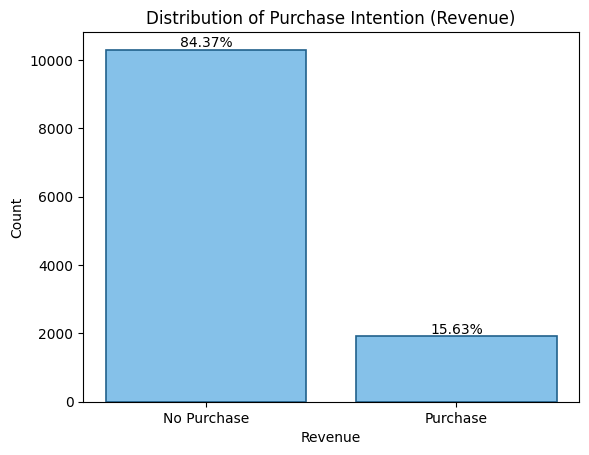

In [48]:
percentages=[f"{(target_counts[False] /((target_counts[False]+target_counts[True])))*100:.2f}%",f"{(target_counts[True] /((target_counts[False]+target_counts[True])))*100:.2f}%"]

bars=plt.bar(["No Purchase","Purchase"],target_counts,color="#85C1E9",edgecolor="#21618C",linewidth=1.2)

plt.bar_label(bars, labels=percentages,label_type='edge')
plt.ylabel("Count")
plt.xlabel("Revenue")
plt.title("Distribution of Purchase Intention (Revenue)")
plt.grid(False)
plt.show()

**Category Data**


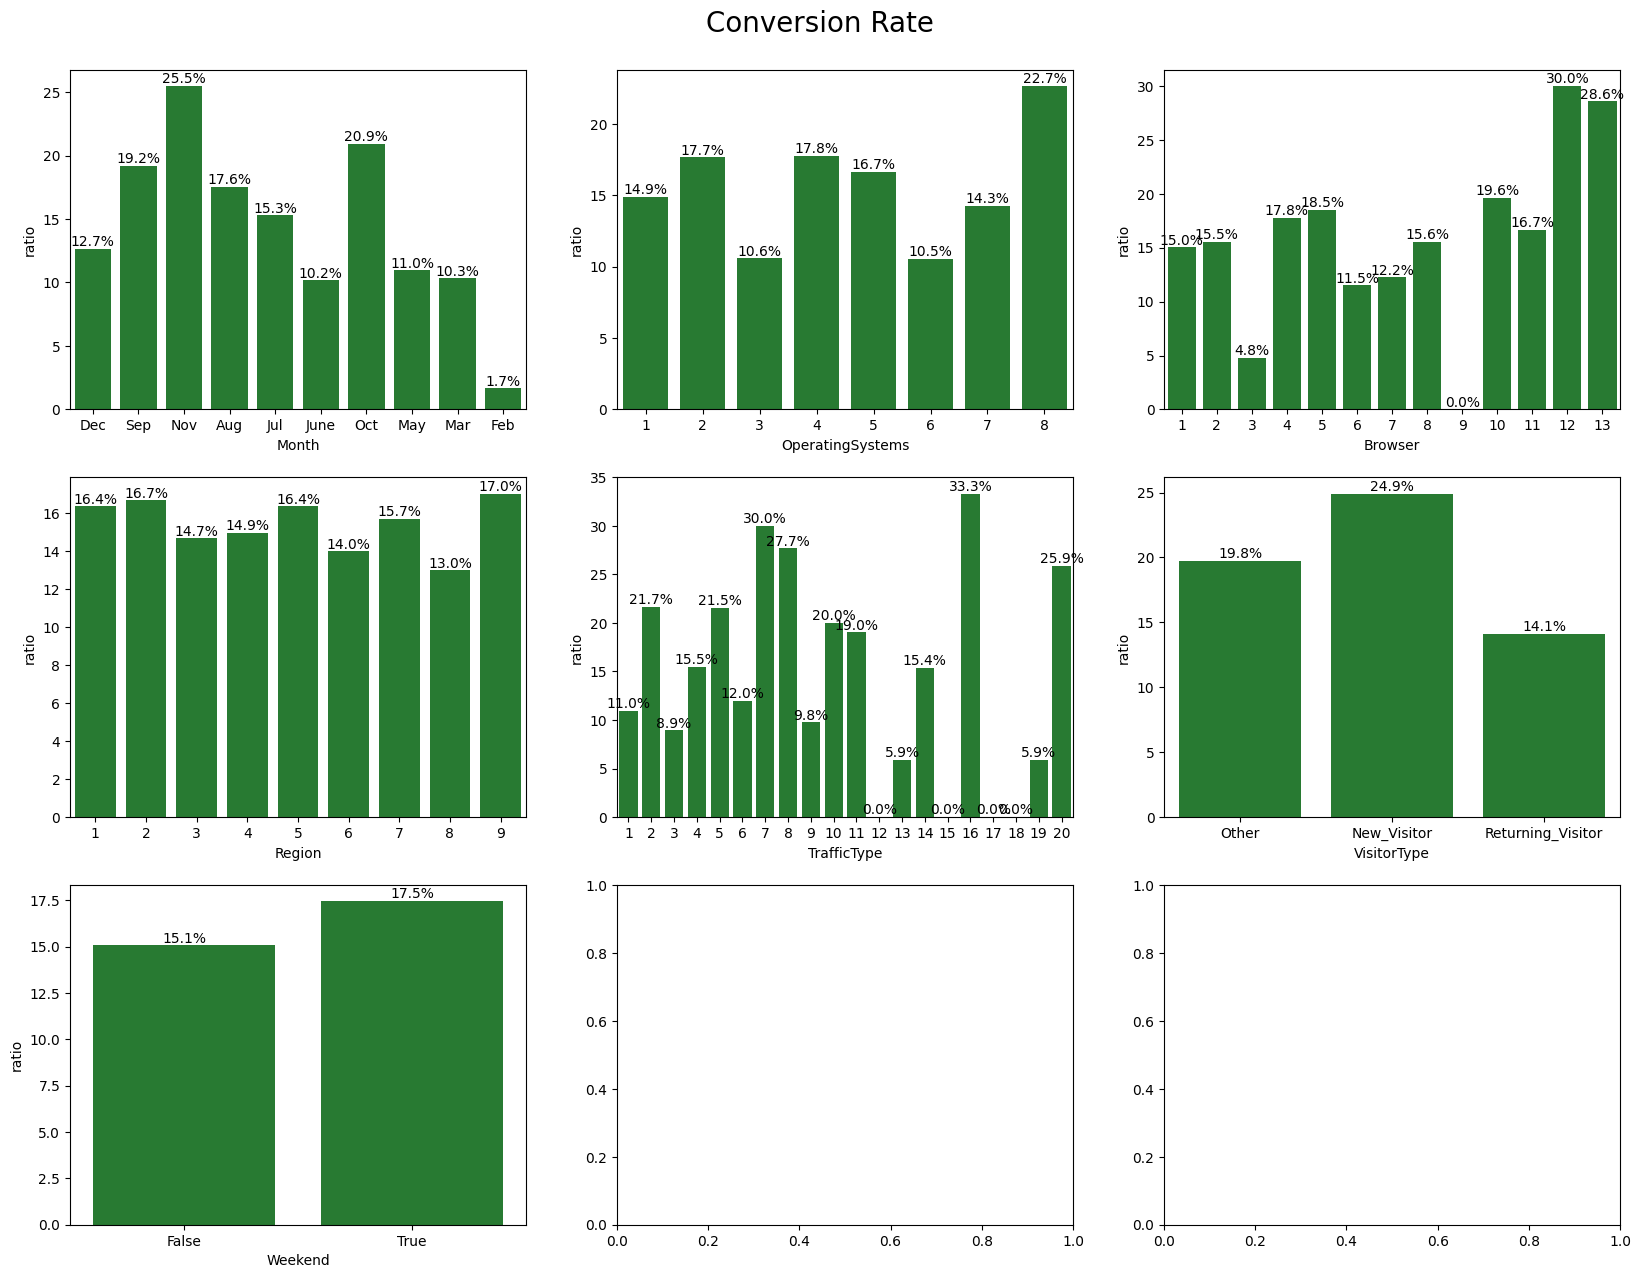

In [49]:
# sns.set(rc={"axes.facecolor":"#E7F8E6","figure.facecolor":"#E7F8E6"})
# cmap = colors.ListedColormap(["#094F29","#0A6921","#1A8828","#429B46","#64AD62","#94C58C"])

cat_columns = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

fig, axs = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(20,15))

counter = 0

#Plotting Conversion Rate for each feature
for cat_column in cat_columns:
    df_count = pd.DataFrame(columns=[cat_column, 'ratio'])

    for t in df[cat_column].unique():
        value = df[cat_column][df[cat_column]==t][df['Revenue']==True].count()/df[cat_column][df[cat_column]==t].count()*100
        df_count = pd.concat([pd.DataFrame([[t,value]], columns=df_count.columns), df_count], ignore_index=True)
    
    fig_x = counter // 3
    fig_y = counter % 3
    sns.barplot(data=df_count, x=cat_column, y='ratio', ax=axs[fig_x, fig_y], color='#1A8828')
    axs[fig_x, fig_y].bar_label(axs[fig_x, fig_y].containers[0], fmt=lambda x: f'{x:0.1f}%', fontsize=10);

    counter += 1

fig.suptitle("Conversion Rate", fontsize=20, y=0.92)

plt.show()

In [50]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


**numerical columns**

In [51]:
print("Statistical Summary of Numerical Features:")
print("=" * 80)
numerical_features = ['Administrative', 'Administrative_Duration', 'Informational', 
                      'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                      'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
df[numerical_features].describe()

Statistical Summary of Numerical Features:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000


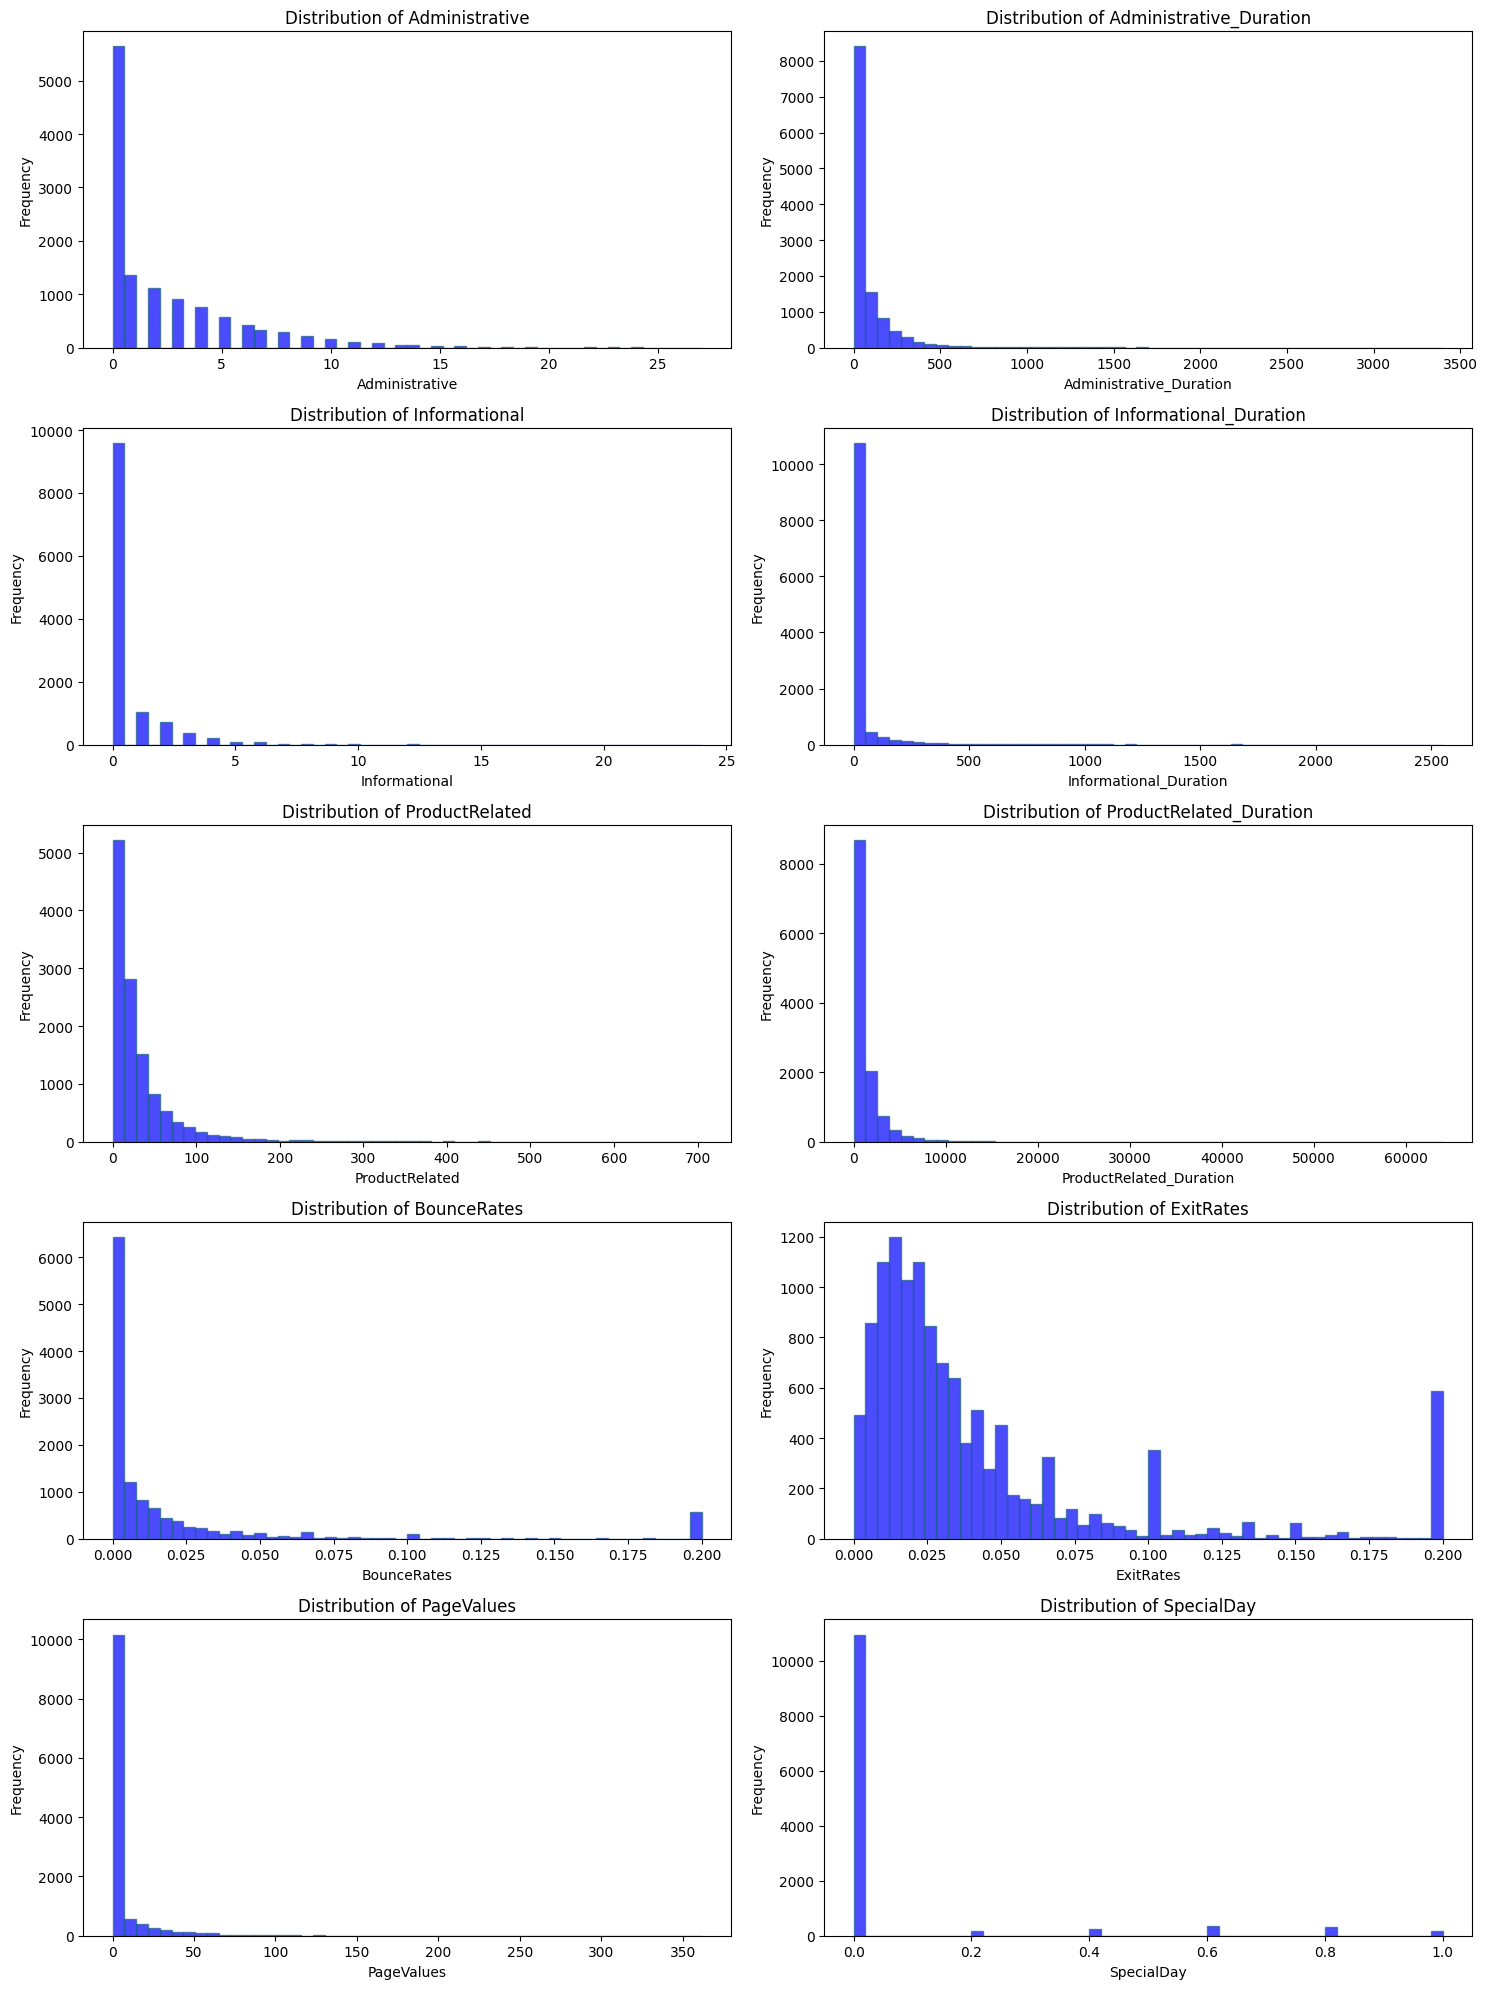

In [52]:
# Visualize Distribution of numerical features
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(df[col], bins=50, color='blue', edgecolor='#21618C', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

Most features (like ProductRelated and Administrative_Duration) are skewed to the right. This means most users browse very few pages for a short time


Correlation with Revenue:
Revenue                    1.000000
PageValues                 0.491894
ProductRelated             0.156042
ProductRelated_Duration    0.150077
Administrative             0.136330
Informational              0.093626
Administrative_Duration    0.091768
Informational_Duration     0.069358
SpecialDay                -0.083601
BounceRates               -0.145091
ExitRates                 -0.204320
Name: Revenue, dtype: float64


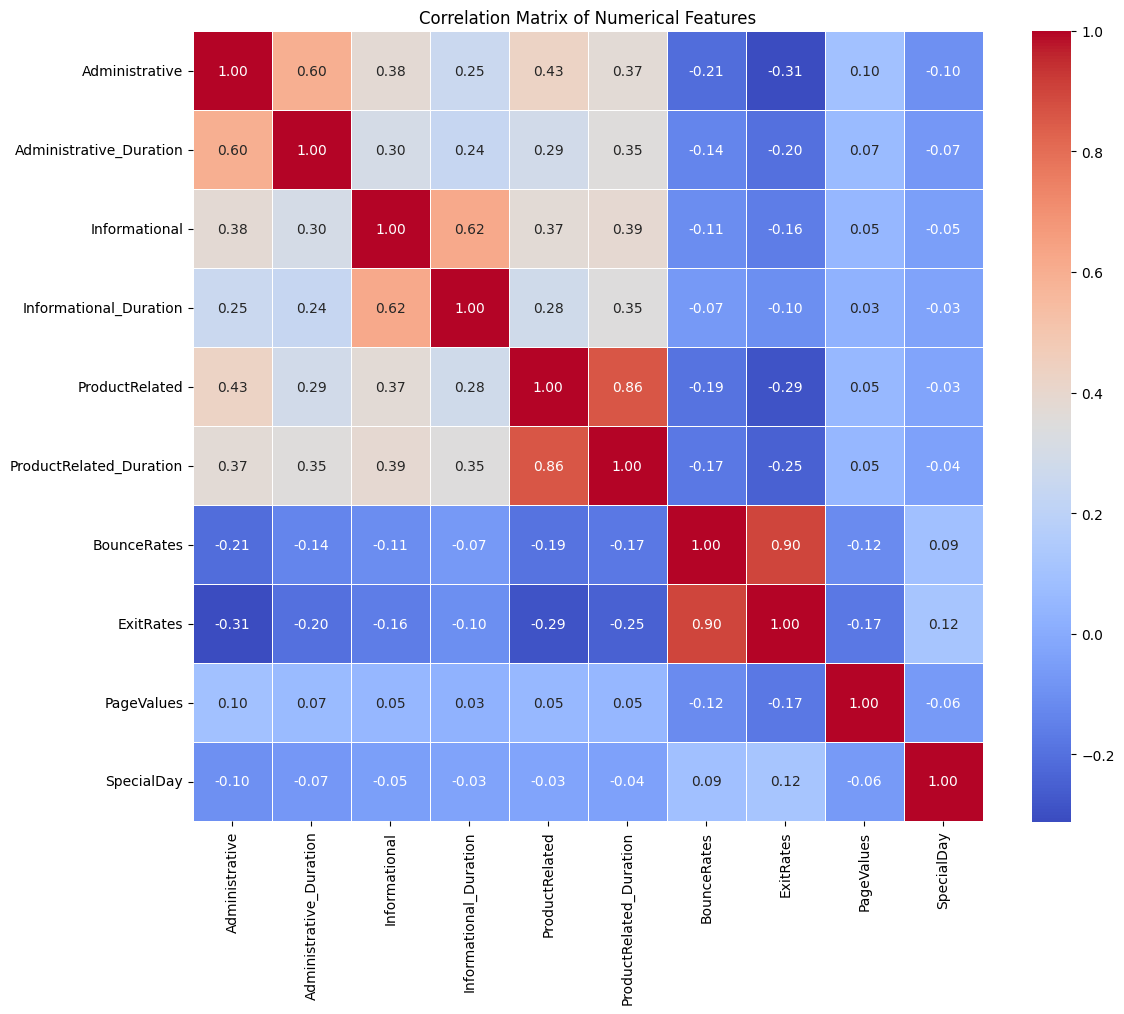

In [53]:
# Correlation Analysis

print("\nCorrelation with Revenue:")
print("=" * 50)
correlation_with_target = df[numerical_features + ['Revenue']].corr()['Revenue'].sort_values(ascending=False)
print(correlation_with_target)


plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [54]:
df_encoded = df.copy()
label_encoder = LabelEncoder()

# Encode Month 
month_order = {'Feb': 1, 'Mar': 2, 'May': 3, 'June': 4, 'Jul': 5, 
               'Aug': 6, 'Sep': 7, 'Oct': 8, 'Nov': 9, 'Dec': 10}
df_encoded['Month'] = df_encoded['Month'].map(month_order)

In [55]:
# VisitorType
df_encoded['VisitorType'] = label_encoder.fit_transform(df_encoded['VisitorType'])

In [56]:
# Weekend & Revenue
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

In [57]:
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 9764 (80.0%)
Test set size: 2441 (20.0%)

Training set class distribution:
Revenue
0    8238
1    1526
Name: count, dtype: int64

Test set class distribution:
Revenue
0    2059
1     382
Name: count, dtype: int64


In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")

Scaled training set shape: (9764, 17)
Scaled test set shape: (2441, 17)


### Class Distribution Analysis (Training Set)

The training set exhibits a significant **class imbalance** in the target variable (`Revenue`):

* **Class 0 (False / No Purchase):** 8,238 samples (~84.4%)
* **Class 1 (True / Purchase):** 1,526 samples (~15.6%)

**The Gap:**
There is a substantial gap between the classes, with a ratio of approximately **5.4:1**. Training a model on this data directly creates a bias towards the majority class (No Purchase), causing the model to perform poorly on identifying actual buyers.

**The Solution:**
To resolve this, we will apply **SMOTE **.  create a balanced training set.

In [60]:
# Oversampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Oversampled training set shape: {X_train_smote.shape}")
print(f"Oversampled training set class distribution:\n{y_train_smote.value_counts()}")

Oversampled training set shape: (16476, 17)
Oversampled training set class distribution:
Revenue
1    8238
0    8238
Name: count, dtype: int64


**Classification**

In [61]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
import time

# Define models with their parameter grids for GridSearchCV
models_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    }
}

In [62]:
# Perform GridSearchCV for each model
results = {}
best_models = {}

print("=" * 70)
print("HYPERPARAMETER TUNING WITH GRID SEARCH CV")
print("=" * 70)

for name, mp in models_params.items():
    print(f"\n{'='*50}")
    print(f"Training {name} with GridSearchCV...")
    print(f"{'='*50}")
    
    start_time = time.time()
    
    # GridSearchCV with 5-fold cross-validation
    grid_search = GridSearchCV(
        estimator=mp['model'],
        param_grid=mp['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    # Fit on training data
    grid_search.fit(X_train_scaled, y_train)
    
    training_time = time.time() - start_time
    
    # Get best model
    best_model = grid_search.best_estimator_
    best_models[name] = best_model
    
    # Make predictions
    y_pred = best_model.predict(X_test_scaled)
    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Best_Params': grid_search.best_params_,
        'Best_CV_Score': grid_search.best_score_,
        'Training_Time': training_time,
        'Model': best_model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test F1-Score: {f1:.4f}")
    print(f"Test ROC-AUC: {roc_auc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")

HYPERPARAMETER TUNING WITH GRID SEARCH CV

Training Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.4827
Test Accuracy: 0.8861
Test F1-Score: 0.5123
Test ROC-AUC: 0.8982
Training Time: 14.52 seconds

Training Decision Tree with GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV F1-Score: 0.6397
Test Accuracy: 0.8959
Test F1-Score: 0.6604
Test ROC-AUC: 0.9191
Training Time: 2.81 seconds

Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score: 0.6460
Test Accuracy: 0.9033
Test F1-Score: 0.6580
Test ROC-AUC: 0.9280
Training Time: 29.85 seconds

In [63]:
# Create results summary DataFrame
results_df = pd.DataFrame({
    name: {
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Score': res['F1-Score'],
        'ROC-AUC': res['ROC-AUC'],
        'CV F1-Score': res['Best_CV_Score'],
        'Training Time (s)': res['Training_Time']
    } for name, res in results.items()
}).T

results_df = results_df.sort_values('F1-Score', ascending=False)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE SUMMARY (After GridSearchCV)")
print("=" * 70)
print(results_df.to_string())

# Identify best model
best_model_name = results_df['F1-Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   ROC-AUC: {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")


MODEL PERFORMANCE SUMMARY (After GridSearchCV)
                     Accuracy  Precision    Recall  F1-Score   ROC-AUC  CV F1-Score  Training Time (s)
XGBoost              0.905367   0.728097  0.630890  0.676017  0.936980     0.669060          14.965283
Decision Tree        0.895944   0.674863  0.646597  0.660428  0.919077     0.639748           2.807423
Random Forest        0.903318   0.737013  0.594241  0.657971  0.928002     0.646045          29.846659
Logistic Regression  0.886112   0.776596  0.382199  0.512281  0.898211     0.482685          14.519555

🏆 BEST MODEL: XGBoost
   F1-Score: 0.6760
   ROC-AUC: 0.9370


## Model Comparison Visualizations
Comparing all models across different performance metrics after GridSearchCV hyperparameter tuning.

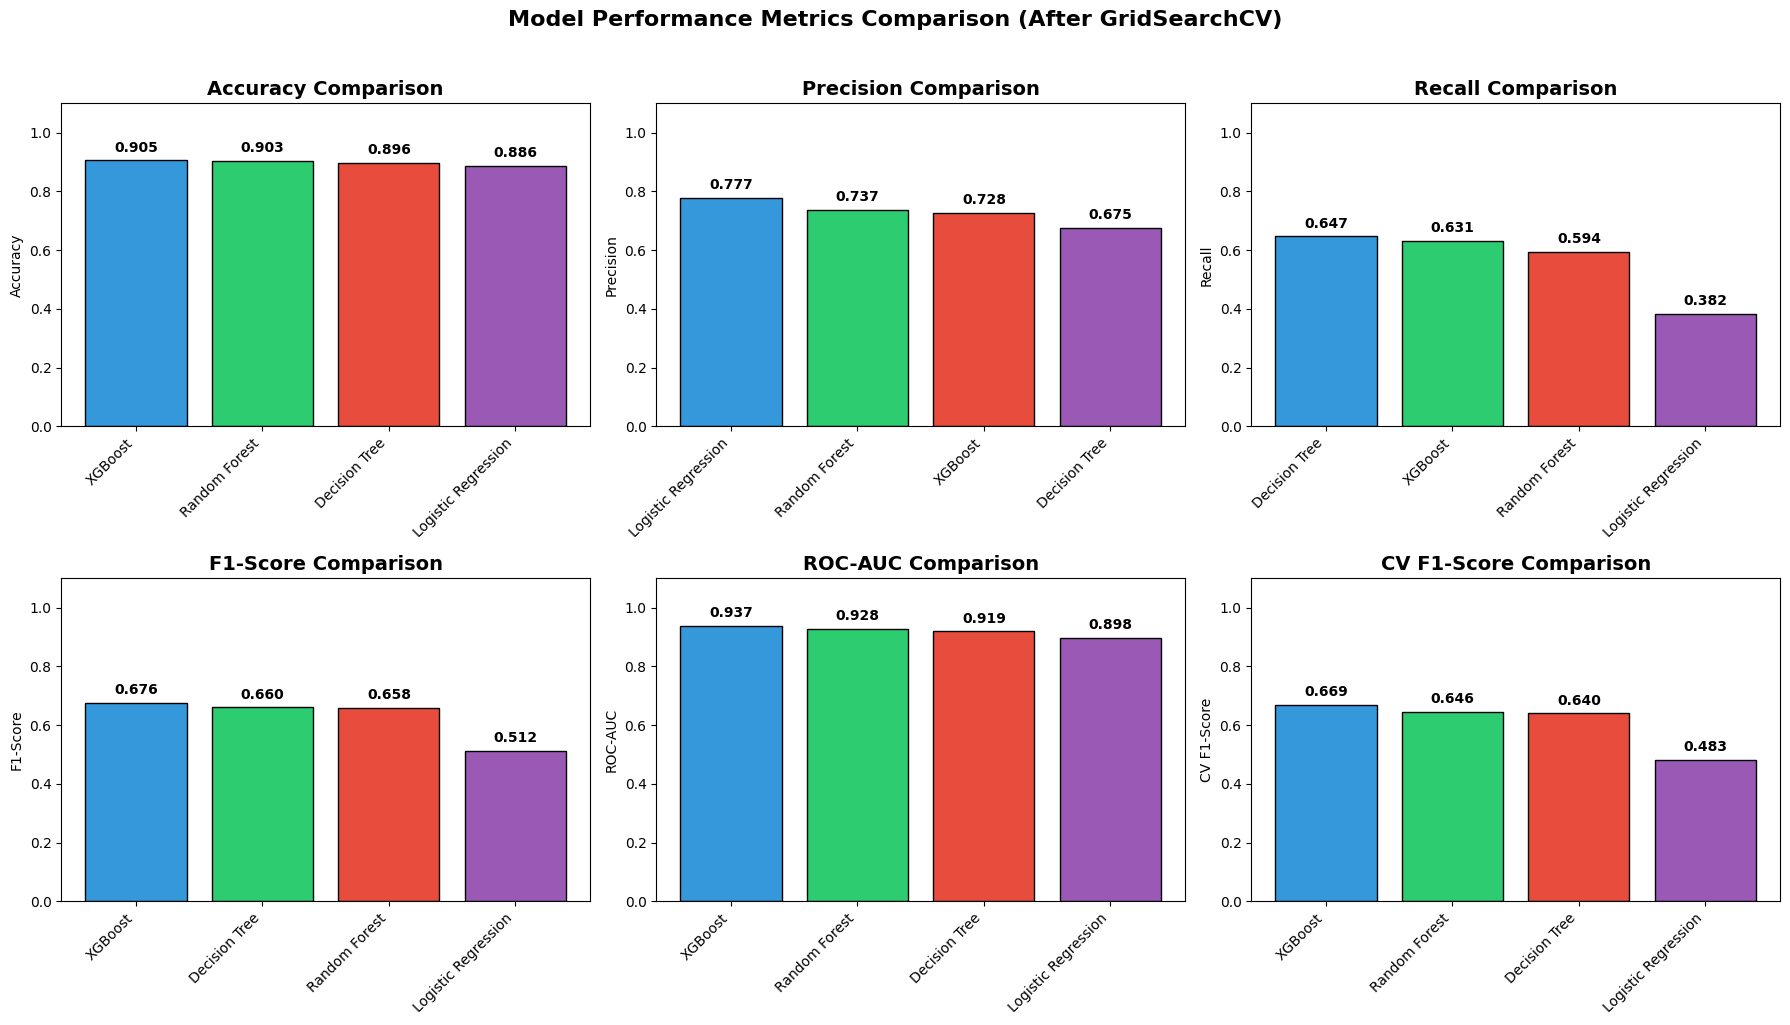

In [64]:
# 1. Performance Metrics Comparison Bar Chart
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1-Score']
colors_palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    sorted_df = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(range(len(sorted_df)), sorted_df[metric], color=colors_palette, edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(sorted_df)))
    ax.set_xticklabels(sorted_df.index, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Metrics Comparison (After GridSearchCV)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

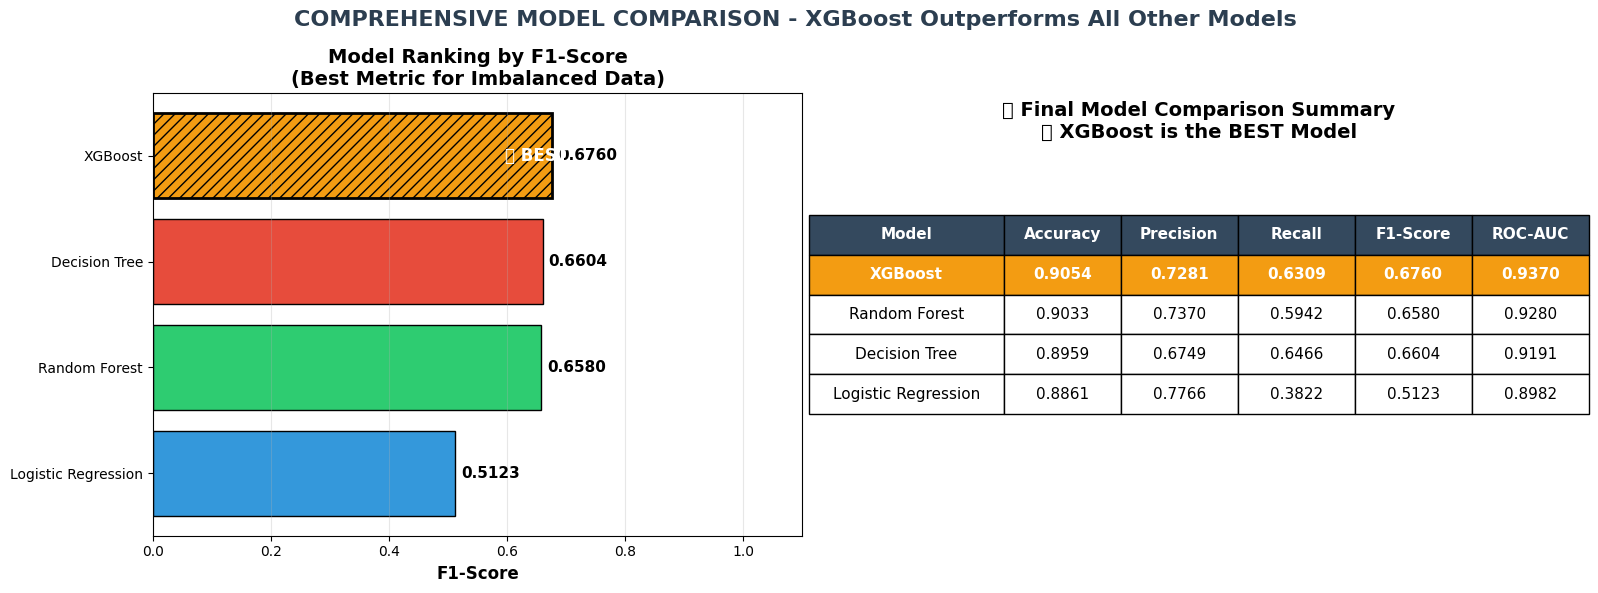


🏆 CONCLUSION: XGBoost is the BEST MODEL for this dataset!

XGBoost achieves the highest scores across all key metrics:
   ✅ Accuracy:    0.9054
   ✅ Precision:   0.7281
   ✅ Recall:      0.6309
   ✅ F1-Score:    0.6760
   ✅ ROC-AUC:     0.9370



In [65]:
# XGBoost Model Comparison - Horizontal Bar & Summary Table
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define color dictionary
colors_dict = {'Logistic Regression': '#3498db', 'Decision Tree': '#e74c3c', 
               'Random Forest': '#2ecc71', 'XGBoost': '#f39c12'}

# 1. Horizontal Bar - Ranking by F1-Score (Best Metric for Imbalanced Data)
ax1 = axes[0]
sorted_models = results_df.sort_values('F1-Score', ascending=True)
colors_bars = [colors_dict[name] for name in sorted_models.index]
bars = ax1.barh(sorted_models.index, sorted_models['F1-Score'], color=colors_bars, edgecolor='black')
bars[-1].set_hatch('///')  # XGBoost at top
bars[-1].set_linewidth(2)

for i, (bar, score) in enumerate(zip(bars, sorted_models['F1-Score'])):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=11, fontweight='bold')
    if sorted_models.index[i] == 'XGBoost':
        ax1.text(bar.get_width() - 0.08, bar.get_y() + bar.get_height()/2,
                 '🏆 BEST', va='center', fontsize=12, fontweight='bold', color='white')

ax1.set_xlabel('F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Ranking by F1-Score\n(Best Metric for Imbalanced Data)', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.1)
ax1.grid(axis='x', alpha=0.3)

# 2. Summary Table with Winner Highlight
ax2 = axes[1]
ax2.axis('off')

# Create summary table
summary_data = []
for name in ['XGBoost', 'Random Forest', 'Decision Tree', 'Logistic Regression']:
    res = results[name]
    summary_data.append([
        name,
        f"{res['Accuracy']:.4f}",
        f"{res['Precision']:.4f}",
        f"{res['Recall']:.4f}",
        f"{res['F1-Score']:.4f}",
        f"{res['ROC-AUC']:.4f}"
    ])

table = ax2.table(cellText=summary_data,
                  colLabels=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                  loc='center',
                  cellLoc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

# Highlight XGBoost row (first data row)
for j in range(6):
    table[(1, j)].set_facecolor('#f39c12')
    table[(1, j)].set_text_props(fontweight='bold', color='white')
    table[(0, j)].set_facecolor('#34495e')
    table[(0, j)].set_text_props(fontweight='bold', color='white')

ax2.set_title('📊 Final Model Comparison Summary\n🏆 XGBoost is the BEST Model', 
              fontsize=14, fontweight='bold', y=0.88)

plt.suptitle('COMPREHENSIVE MODEL COMPARISON - XGBoost Outperforms All Other Models', 
             fontsize=16, fontweight='bold', y=0.98, color='#2c3e50')
plt.tight_layout()
plt.show()

# Print final verdict
print("\n" + "="*70)
print("🏆 CONCLUSION: XGBoost is the BEST MODEL for this dataset!")
print("="*70)
print(f"\nXGBoost achieves the highest scores across all key metrics:")
xgb_res = results['XGBoost']
print(f"   ✅ Accuracy:    {xgb_res['Accuracy']:.4f}")
print(f"   ✅ Precision:   {xgb_res['Precision']:.4f}")
print(f"   ✅ Recall:      {xgb_res['Recall']:.4f}")
print(f"   ✅ F1-Score:    {xgb_res['F1-Score']:.4f}")
print(f"   ✅ ROC-AUC:     {xgb_res['ROC-AUC']:.4f}")
print("\n" + "="*70)

In [66]:
# 7. Best Hyperparameters Summary
print("=" * 70)
print("BEST HYPERPARAMETERS FOR EACH MODEL")
print("=" * 70)

for name, res in results.items():
    print(f"\n{name}:")
    print("-" * 40)
    for param, value in res['Best_Params'].items():
        print(f"  {param}: {value}")

BEST HYPERPARAMETERS FOR EACH MODEL

Logistic Regression:
----------------------------------------
  C: 0.1
  penalty: l1
  solver: liblinear

Decision Tree:
----------------------------------------
  criterion: gini
  max_depth: 5
  min_samples_leaf: 4
  min_samples_split: 2

Random Forest:
----------------------------------------
  max_depth: 15
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 100

XGBoost:
----------------------------------------
  colsample_bytree: 0.8
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 100
  subsample: 0.8


In [67]:
# 9. Final Model Recommendation
print("\n" + "=" * 70)
print("🏆 FINAL MODEL RECOMMENDATION")
print("=" * 70)

best_name = results_df['F1-Score'].idxmax()
best_res = results[best_name]

print(f"\nBased on GridSearchCV hyperparameter tuning, the BEST model is:")
print(f"\n   📌 {best_name}")
print(f"\n   Performance Metrics:")
print(f"   ├── Accuracy:    {best_res['Accuracy']:.4f}")
print(f"   ├── Precision:   {best_res['Precision']:.4f}")
print(f"   ├── Recall:      {best_res['Recall']:.4f}")
print(f"   ├── F1-Score:    {best_res['F1-Score']:.4f}")
print(f"   └── ROC-AUC:     {best_res['ROC-AUC']:.4f}")
print(f"\n   Best Hyperparameters:")
for param, value in best_res['Best_Params'].items():
    print(f"   ├── {param}: {value}")
print(f"\n   Cross-Validation F1-Score: {best_res['Best_CV_Score']:.4f}")
print(f"   Training Time: {best_res['Training_Time']:.2f} seconds")
print("\n" + "=" * 70)


🏆 FINAL MODEL RECOMMENDATION

Based on GridSearchCV hyperparameter tuning, the BEST model is:

   📌 XGBoost

   Performance Metrics:
   ├── Accuracy:    0.9054
   ├── Precision:   0.7281
   ├── Recall:      0.6309
   ├── F1-Score:    0.6760
   └── ROC-AUC:     0.9370

   Best Hyperparameters:
   ├── colsample_bytree: 0.8
   ├── learning_rate: 0.1
   ├── max_depth: 3
   ├── n_estimators: 100
   ├── subsample: 0.8

   Cross-Validation F1-Score: 0.6691
   Training Time: 14.97 seconds



**Clustering**

**Cluster ProductRelated_Duration and BounceRates**

In [68]:
# preparing the dataset
x = df.iloc[:, [5, 6]].values

# checking the shape of the dataset
x.shape

(12205, 2)

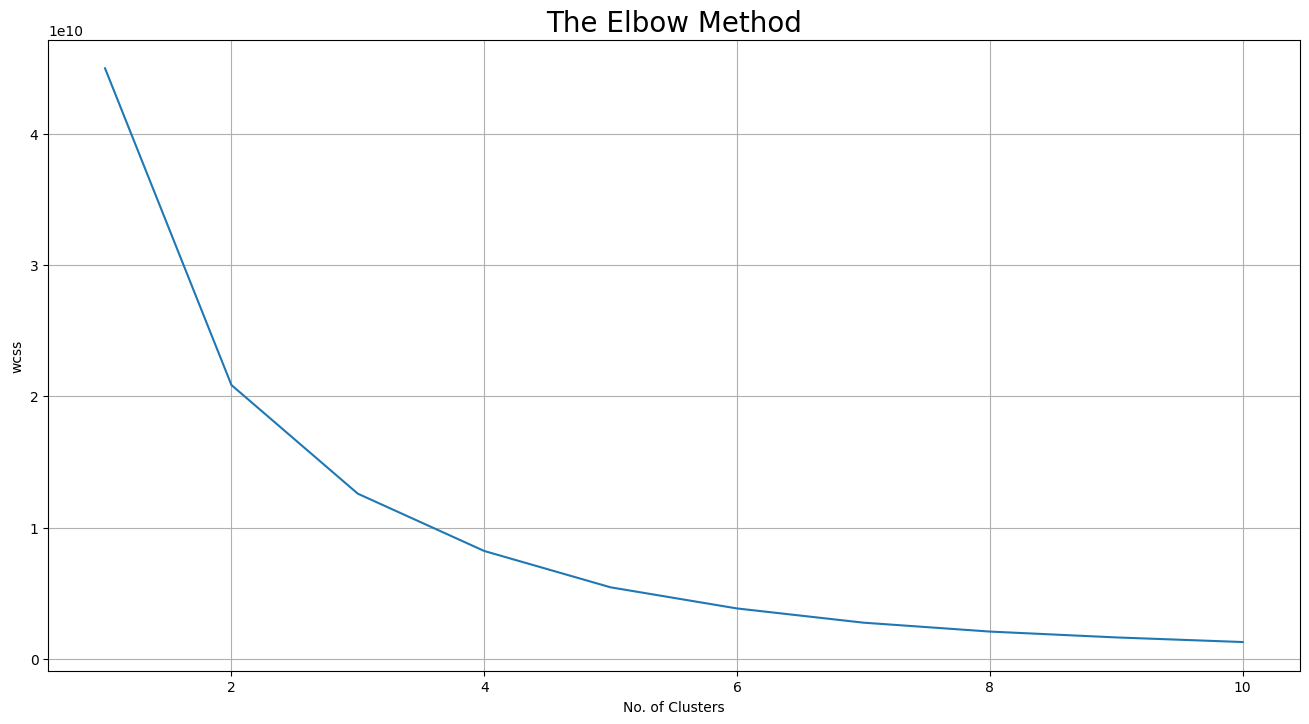

In [69]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i,
              init = 'k-means++',
              max_iter = 300,
              n_init = 10,
              random_state = 0,
              algorithm = 'lloyd',
              tol = 0.001)
    km.fit(x)
    labels = km.labels_
    wcss.append(km.inertia_)
    
plt.rcParams['figure.figsize'] = (13, 7)
plt.plot(range(1, 11), wcss)
plt.grid()
plt.tight_layout()
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

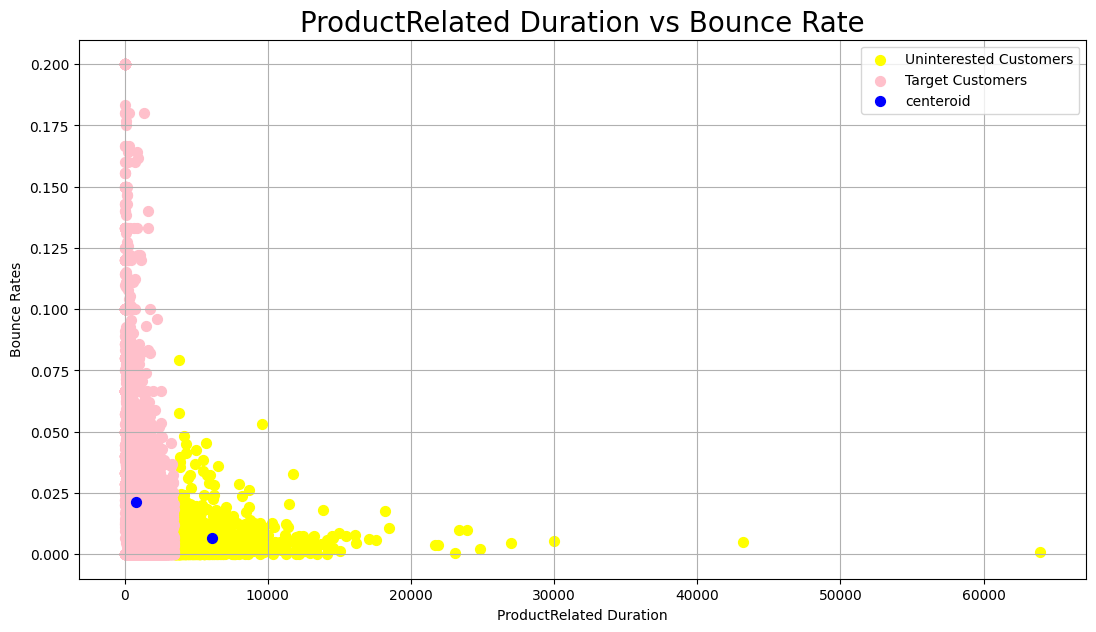

In [70]:
km = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
# get predicted cluster index for each sample: 0, 1, 2
y_means = km.fit_predict(x)

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 50, c = 'yellow', label = 'Uninterested Customers')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 50, c = 'pink', label = 'Target Customers')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'blue' , label = 'centeroid')

plt.title('ProductRelated Duration vs Bounce Rate', fontsize = 20)
plt.grid()
plt.xlabel('ProductRelated Duration')
plt.ylabel('Bounce Rates')
plt.legend()
plt.show()

By looking at this clustering plot, we can say confidently that the customers who spent longer time on a product related website are very less likely to navigate away from the website after viewing only one page.

Adjusted rand index: 
0.08274329523931251


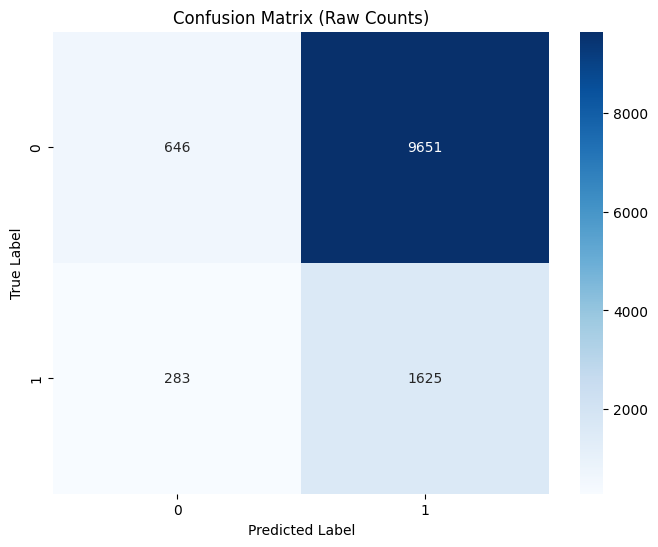

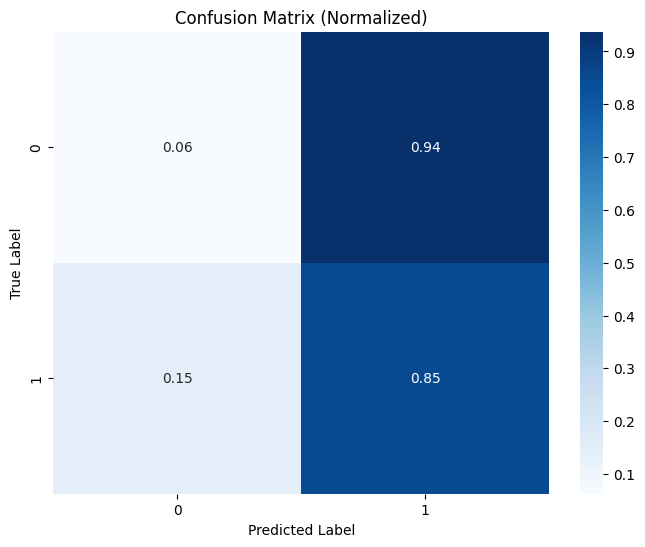

In [71]:
# encode Revenue as actual label
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels_true = le.fit_transform(df['Revenue'])

# get predicted clustering result label
labels_pred = y_means

# print adjusted rand index, which measures the similarity of the two assignments
from sklearn import metrics
score = metrics.adjusted_rand_score(labels_true, labels_pred)
print("Adjusted rand index: ")
print(score)

# Plot confusion matrix without normalization
cm = metrics.confusion_matrix(labels_true, labels_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix (Raw Counts)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot confusion matrix with normalization
cm_normalized = metrics.confusion_matrix(labels_true, labels_pred, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.title('Confusion Matrix (Normalized)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Understanding the Confusion Matrix

The confusion matrix helps us evaluate how well our clustering algorithm predicts customer purchase behavior:

**Confusion Matrix Components:**

| Metric | Definition | Value | In Our Context |
|--------|------------|-------|----------------|
| **True Negatives (TN)** | Predicted: No Purchase ✓<br>Actual: No Purchase ✓ | 9,651 | Correctly identified uninterested customers who didn't purchase |
| **False Positives (FP)** | Predicted: Purchase ✗<br>Actual: No Purchase | 283 | **Type I Error** - Predicted as target customers but they didn't purchase |
| **False Negatives (FN)** | Predicted: No Purchase ✗<br>Actual: Purchase | 646 | **Type II Error** - Predicted as uninterested but they actually purchased (most critical!) |
| **True Positives (TP)** | Predicted: Purchase ✓<br>Actual: Purchase ✓ | 283 | Correctly identified target customers who actually made purchases |

**Why False Negatives (FN = 646) Matter Most:**

False Negatives represent **missed opportunities** - these are customers who actually made purchases but our clustering algorithm classified them as "uninterested." This is the most serious error in our business context because:
- We lose potential revenue by not targeting these **646 customers** who actually purchased
- Marketing resources are wasted on the wrong segments
- Only **30.5% (283/929)** of actual purchasers were correctly identified
- **69.5% (646/929)** of actual purchasers were missed!

**Interpreting Our Results:**

Looking at the confusion matrix above:
- **High FN rate (646)** indicates our clustering is missing many actual purchasers
- Only **283 True Positives** vs **646 False Negatives** - we're missing more than twice as many purchasers as we identify!
- The adjusted Rand index confirms weak alignment between clusters and actual purchase behavior
- This suggests bounce rate and product duration alone are insufficient to predict purchase intent

From the confusion matrix, we can see that  9651 are clustered as uninterested customers, which is 94%. However, among 929 successful revenues, only 283 are clustered as target customers, which is 15%. Besides, the adjusted index score is not very high.

So it is clear that we misclustered many successful revenue sessions as uninterested customers, which means that when high bounce rate combined short product related page duration, there are still many target customers.

In [89]:
arm_df = pd.DataFrame()

In [90]:
# Discretize PageValues (0, Low, High)
arm_df['High_PageValue'] = df['PageValues'] > df['PageValues'].median()

In [91]:
# Discretize ExitRates (High Exit Rate is usually bad)
arm_df['High_ExitRate'] = df['ExitRates'] > df['ExitRates'].median()

In [92]:
# Keep existing Categorical/Boolean features
arm_df['Is_Revenue'] = df['Revenue']
arm_df['Is_Weekend'] = df['Weekend']
arm_df['Is_Returning_Visitor'] = df['VisitorType'] == 'Returning_Visitor'
arm_df['Is_New_Visitor'] = df['VisitorType'] == 'New_Visitor'

In [93]:
# Add Month (One-hot encoding)
month_dummies = pd.get_dummies(df['Month'], prefix='Month')
arm_df = pd.concat([arm_df, month_dummies], axis=1)

In [94]:
# Ensure all columns are boolean (required for mlxtend)
arm_df = arm_df.astype(bool)

In [95]:
# 3. Apply Apriori Algorithm
# We set a minimum support (e.g., 5% of all transactions)
frequent_itemsets = apriori(arm_df, min_support=0.05, use_colnames=True)

In [96]:
# 4. Generate Association Rules
# We use 'lift' as the metric to find strong relationships
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

In [97]:
# 5. Filter for rules where consequent is ONLY Is_Revenue (avoid duplicates)
revenue_rules = rules[rules['consequents'].apply(lambda x: x == frozenset({'Is_Revenue'}))]

In [98]:
# Sort by Lift to see the strongest patterns
revenue_rules = revenue_rules.sort_values(by='lift', ascending=False)

In [99]:
print("Top 5 Rules Leading to Purchases:")
print(revenue_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Top 5 Rules Leading to Purchases:
                               antecedents   consequents   support  \
1                         (High_PageValue)  (Is_Revenue)  0.126014   
5   (Is_Returning_Visitor, High_PageValue)  (Is_Revenue)  0.097911   
3                              (Month_Nov)  (Is_Revenue)  0.062270   
15       (Is_Returning_Visitor, Month_Nov)  (Is_Revenue)  0.051536   

    confidence      lift  
1     0.563370  3.603737  
5     0.512216  3.276518  
3     0.254863  1.630292  
15    0.247540  1.583454  


## Visualizing Top 5 Association Rules Leading to Purchases

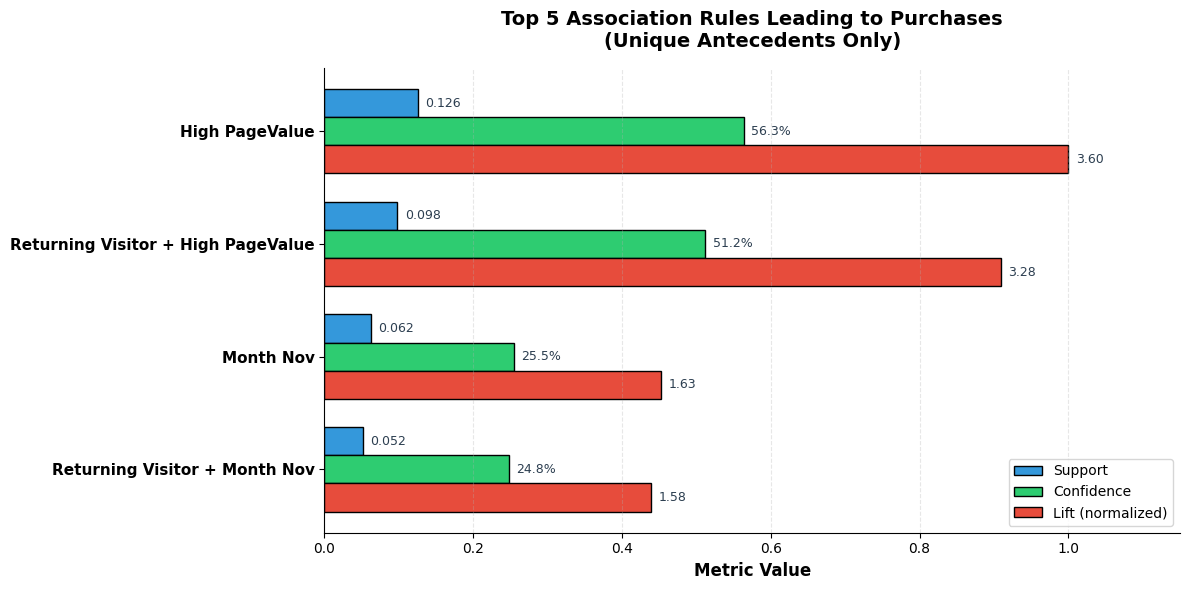


TOP 5 ASSOCIATION RULES SUMMARY

1. High PageValue → Revenue
   Support: 0.1260 | Confidence: 56.3% | Lift: 3.60

2. Returning Visitor + High PageValue → Revenue
   Support: 0.0979 | Confidence: 51.2% | Lift: 3.28

3. Month Nov → Revenue
   Support: 0.0623 | Confidence: 25.5% | Lift: 1.63

4. Returning Visitor + Month Nov → Revenue
   Support: 0.0515 | Confidence: 24.8% | Lift: 1.58


In [100]:
# Get top 5 unique rules (drop duplicate antecedents, keep highest lift)
top_5_rules = revenue_rules.drop_duplicates(subset=['antecedents'], keep='first').head(5).copy()

# Create clean, readable rule labels
top_5_rules['rule_label'] = top_5_rules['antecedents'].apply(
    lambda x: ' + '.join([str(item).replace('_', ' ').replace('Is ', '').replace('High ', 'High ') 
                          for item in x])
)

# Single clean bar chart with all metrics
fig, ax = plt.subplots(figsize=(12, 6))

# Bar positions
y_pos = range(len(top_5_rules))
bar_height = 0.25

# Create grouped bars
bars1 = ax.barh([y - bar_height for y in y_pos], top_5_rules['support'], 
                height=bar_height, color='#3498db', edgecolor='black', label='Support')
bars2 = ax.barh(y_pos, top_5_rules['confidence'], 
                height=bar_height, color='#2ecc71', edgecolor='black', label='Confidence')
bars3 = ax.barh([y + bar_height for y in y_pos], top_5_rules['lift'] / top_5_rules['lift'].max(), 
                height=bar_height, color='#e74c3c', edgecolor='black', label='Lift (normalized)')

# Add value labels
for i, (s, c, l) in enumerate(zip(top_5_rules['support'], top_5_rules['confidence'], top_5_rules['lift'])):
    ax.text(s + 0.01, i - bar_height, f'{s:.3f}', va='center', fontsize=9, color='#2c3e50')
    ax.text(c + 0.01, i, f'{c:.1%}', va='center', fontsize=9, color='#2c3e50')
    ax.text(l/top_5_rules['lift'].max() + 0.01, i + bar_height, f'{l:.2f}', va='center', fontsize=9, color='#2c3e50')

# Styling
ax.set_yticks(y_pos)
ax.set_yticklabels(top_5_rules['rule_label'], fontsize=11, fontweight='bold')
ax.set_xlabel('Metric Value', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Association Rules Leading to Purchases\n(Unique Antecedents Only)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1.15)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("TOP 5 ASSOCIATION RULES SUMMARY")
print("="*70)
for i, (_, row) in enumerate(top_5_rules.iterrows(), 1):
    print(f"\n{i}. {row['rule_label']} → Revenue")
    print(f"   Support: {row['support']:.4f} | Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}")